In [3]:
import numpy as np, pandas as pd, scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut

In [4]:
PFC = ["dorsolateral prefrontal cortex", "prefrontal cortex", "frontal cortex", "Brodmann (1909) area 9", "Brodmann (1909) area 46"]
HELD = ["37a17b78", "6f7fd0f1", "5e57cd50"]

cells = pd.read_parquet("data/brain/cells.parquet").reset_index(drop=True)
ct    = pd.read_parquet("data/brain/cell_types.parquet").reset_index(drop=True)
plan  = pd.read_parquet("data/brain/plan.parquet").drop_duplicates("pid")
X     = sp.load_npz("data/brain/counts_hv.npz").tocsr()

In [5]:
dom = ct.groupby("pid", observed=True).tissue.agg(lambda s: s.value_counts().index[0])
pfc = set(dom[dom.isin(PFC)].index)

In [6]:
d = plan.disease.str.lower()
is_dem = d.str.contains("dementia|alzheimer") & ~d.str.contains("amyotrophic")
is_nor = d.eq("normal")
lab = plan[plan.pid.isin(pfc) & (is_dem | is_nor)][["pid", "study", "disease"]].copy()
lab["y"] = lab.disease.str.lower().str.contains("dementia|alzheimer").astype(int)
dropped = plan[plan.pid.isin(pfc) & ~(is_dem | is_nor)]
print(f"dropped (PD/ALS-only): {len(dropped)} donors -> {sorted(dropped.study.unique())}")


dropped (PD/ALS-only): 39 donors -> ['37a17b78', '5e57cd50', '98f5d518', 'd3cb449b']


In [7]:
t = lab.groupby("study").y.agg(dementia="sum", n="size")
t["normal"] = t.n - t.dementia
print(f"\n=== clean corpus: {len(lab)} donors | {int(lab.y.sum())} dementia / "
      f"{int((1-lab.y).sum())} normal | {lab.study.nunique()} studies ===")
print(t.sort_values("dementia", ascending=False).to_string())


=== clean corpus: 648 donors | 295 dementia / 353 normal | 15 studies ===
          dementia    n  normal
study                          
37a17b78       143  197      54
5e57cd50        94  120      26
6f7fd0f1        39   83      44
3b8b5de4         9   16       7
cff99df2         8   13       5
0a2d7e87         2    7       5
1a38e762         0   39      39
5c97eeeb         0  145     145
3c361813         0    4       4
07dd8c34         0    3       3
716a4acc         0    3       3
85c60876         0    4       4
9813a1d4         0    4       4
98f5d518         0    5       5
d3cb449b         0    5       5


In [8]:
keep = cells.pid.isin(set(lab.pid)).to_numpy()

Zc = np.load("data/brain/pca50.npy")[keep]       
D, SEED = 1024, 0
rng = np.random.default_rng(SEED)

In [9]:
rows, pid = np.where(keep)[0], cells.pid.to_numpy()[keep]
order = pd.unique(pid)
meta = lab.set_index("pid").loc[order].reset_index()

In [10]:
smp = Zc[rng.choice(len(Zc), 5000, replace=False)]
dd  = np.sqrt(((smp[:, None] - smp[None]) ** 2).sum(-1))
sigma = float(np.median(dd[dd > 0]))

In [11]:
W = (rng.standard_normal((Zc.shape[1], D)) / sigma).astype(np.float32)
b = rng.uniform(0, 2 * np.pi, D).astype(np.float32)
phi = np.sqrt(2.0 / D) * np.cos(Zc @ W + b)
phi

array([[-0.04181879, -0.04306207, -0.03415392, ...,  0.01462622,
         0.04418909, -0.03253248],
       [-0.03891735, -0.03311368, -0.02492167, ...,  0.04043267,
         0.03648928, -0.03833743],
       [-0.04371156, -0.04351559, -0.04394115, ...,  0.0282709 ,
         0.04074415, -0.02580576],
       ...,
       [-0.044005  , -0.03455271, -0.03317677, ...,  0.03415963,
         0.04296476, -0.01205285],
       [-0.02317969, -0.04357782,  0.00297059, ...,  0.00198028,
         0.04050275, -0.03882294],
       [-0.04327547, -0.03276659, -0.03979236, ...,  0.0277915 ,
         0.04414979, -0.01932777]], shape=(258906, 1024))

In [12]:
prow = pd.Series(np.arange(len(order)), index=order).loc[pid].to_numpy()
SIG = np.zeros((len(order), D), np.float32); cnt = np.zeros(len(order))
np.add.at(SIG, prow, phi); np.add.at(cnt, prow, 1.0)
SIG /= cnt[:, None]

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [14]:
def auc_cv(Xa, y, C):
    sc = StandardScaler().fit(Xa)
    pr = cross_val_predict(LogisticRegression(C = C, max_iter = 5000), sc.transform(Xa), y,
                           cv = StratifiedKFold(5, shuffle = True, random_state = 0),
                           method = "predict_proba")[:, 1]
    return roc_auc_score(y, pr)

In [15]:
for st in ["37a17b78", "6f7fd0f1", "5e57cd50"]:
    m = meta[meta.study == st]; y = m.y.to_numpy()
    s = "  ".join(f"C={C}:{auc_cv(SIG[m.index.to_numpy()], y, C):.3f}"
                  for C in [0.0003, 0.001, 0.01, 0.1, 1.0])
    print(f"  {st} n={len(y):3d} ({int(y.sum())} dem)   {s}")

  37a17b78 n=197 (143 dem)   C=0.0003:0.587  C=0.001:0.607  C=0.01:0.619  C=0.1:0.582  C=1.0:0.523
  6f7fd0f1 n= 83 (39 dem)   C=0.0003:0.744  C=0.001:0.744  C=0.01:0.733  C=0.1:0.695  C=1.0:0.679
  5e57cd50 n=120 (94 dem)   C=0.0003:0.531  C=0.001:0.514  C=0.01:0.482  C=0.1:0.483  C=1.0:0.481


In [16]:
comp_col = "cell_type_coarse_brain"
ctype = ct[comp_col].to_numpy()

In [17]:
kpid   = cells.pid.to_numpy()[keep]            
kctype = ct["cell_type_coarse_brain"].to_numpy()[keep]
assert len(kpid) == len(kctype) == len(phi)

In [18]:
def rffmmd_ceiling(comp):
    out = {}
    for st in ["37a17b78", "6f7fd0f1", "5e57cd50"]:
        m = meta[meta.study == st]; yof = dict(zip(m.pid, m.y))
        sel = np.isin(kpid, m.pid.to_numpy()) & (kctype == comp)  
        r   = np.where(sel)[0]
        cp  = kpid[r]
        keep_p = [p for p in m.pid if (cp == p).sum() >= 10]       
        if len({yof[p] for p in keep_p}) < 2 or len(keep_p) < 15:
            out[st] = np.nan; continue
        M  = np.vstack([phi[r[cp == p]].mean(0) for p in keep_p])
        yv = np.array([yof[p] for p in keep_p])
        out[st] = auc_cv(M, yv, 0.01)
    return out

In [19]:
comps = ["Microglia", "Astrocyte", "ExcitatoryNeuron",
         "InhibitoryNeuron", "Oligodendrocyte", "OPC"]
print(pd.DataFrame({c: rffmmd_ceiling(c) for c in comps}).T.round(3).to_string())

                  37a17b78  6f7fd0f1  5e57cd50
Microglia            0.573     0.724     0.378
Astrocyte            0.674     0.643     0.400
ExcitatoryNeuron     0.603     0.766     0.377
InhibitoryNeuron     0.647     0.756     0.236
Oligodendrocyte      0.535     0.701     0.498
OPC                  0.623     0.662     0.383


In [20]:
st = "5e57cd50"

# всё из plan (в нём есть disease, dataset_id, donor_id, y) — по донорам PFC-набора
P = plan[(plan.study == st) & plan.pid.isin(set(meta.pid))][
        ["pid", "dataset_id", "donor_id", "disease", "y"]].drop_duplicates("pid").copy()

# регион и число клеток на донора — отдельными Series, join по pid
reg   = (ct[ct.pid.isin(P.pid)].groupby("pid", observed=True)
         .tissue.agg(lambda s: s.value_counts().index[0]))
ncell = cells[cells.pid.isin(P.pid)].groupby("pid").size()
P["region"]  = P.pid.map(reg)
P["n_cells"] = P.pid.map(ncell)

print(f"=== {st}: {len(P)} donors | {int(P.y.sum())} dem / {int((1-P.y).sum())} normal ===")
print("\ndataset_ids under this study:")
print(P.dataset_id.value_counts().to_string())
print("\nregion x label:")
print(pd.crosstab(P.region, P.y).to_string())
print("\nn_cells per donor by label:")
print(P.groupby("y").n_cells.agg(["count","mean","min","max"]).to_string())
print("\nraw disease labels of y=0 (control) donors:")
print(P[P.y == 0].disease.value_counts().to_string())


=== 5e57cd50: 120 donors | 94 dem / 26 normal ===

dataset_ids under this study:
dataset_id
5e57cd50-8e42-42d6-940d-5c1660d06864    120

region x label:
y                                0   1
region                                
dorsolateral prefrontal cortex  26  94

n_cells per donor by label:
   count       mean  min  max
y                            
0     26  399.50000  387  400
1     94  397.87234  200  400

raw disease labels of y=0 (control) donors:
disease
normal    26


In [21]:
from sklearn.linear_model import LogisticRegression
st = "5e57cd50"
m = meta[meta.study == st]; idx = m.index.to_numpy(); y = m.y.to_numpy()
Xs = SIG[idx]

real = auc_cv(Xs, y, 0.01)
rng = np.random.default_rng(0)
null = []
for _ in range(200):
    yp = rng.permutation(y)
    null.append(auc_cv(Xs, yp, 0.01))
null = np.array(null)
print(f"{st}: real AUC={real:.3f}")
print(f"null: mean={null.mean():.3f}  sd={null.std():.3f}  "
      f"[p2.5={np.percentile(null,2.5):.3f}, p97.5={np.percentile(null,97.5):.3f}]")
print(f"real inside null band? {np.percentile(null,2.5) <= real <= np.percentile(null,97.5)}")


5e57cd50: real AUC=0.482
null: mean=0.498  sd=0.086  [p2.5=0.329, p97.5=0.660]
real inside null band? True


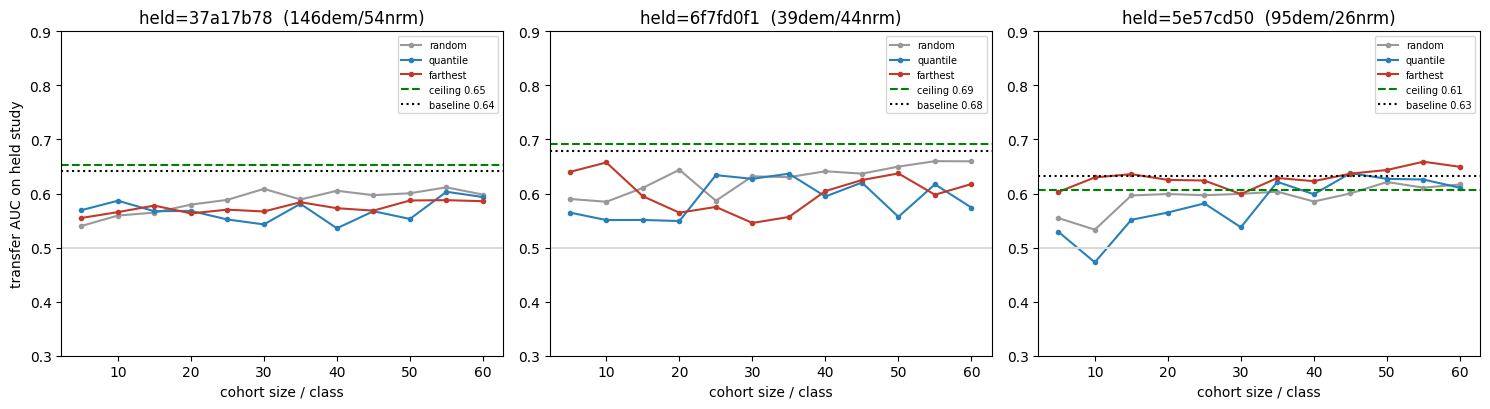

In [22]:
import sys; sys.path.insert(0, "scripts")
from selection import cosine_distance_matrix, greedy_farthest, greedy_quantile
import matplotlib.pyplot as plt

lf = pd.read_parquet("data/brain/signatures_lf_pfc.parquet").reset_index(drop=True)
Sc = [c for c in lf.columns if c.startswith("s") and c[1:].isdigit()]
DEM = ["37a17b78", "6f7fd0f1", "5e57cd50"]
Dall = cosine_distance_matrix(lf[Sc].to_numpy())         

def fit_transfer(tr, held):
    sc = StandardScaler().fit(tr[Sc]); 
    clf = LogisticRegression(C=0.01, max_iter=5000).fit(sc.transform(tr[Sc]), tr.y)
    return roc_auc_score(held.y, clf.predict_proba(sc.transform(held[Sc]))[:, 1])

def pick(idx, k, arm, rng):
    idx = list(idx)
    if len(idx) <= k: return idx
    if arm == "random": return list(rng.choice(idx, k, replace=False))
    seed = [int(rng.choice(idx))]; rest = [i for i in idx if i != seed[0]]
    g = (greedy_farthest(Dall, seed, rest, k-1) if arm == "farthest"
         else greedy_quantile(Dall, seed, rest, k-1, 0.75))
    return seed + g

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, h in zip(axes, DEM):
    held = lf[lf.study == h]; pool = lf[lf.study != h]
    dis = pool.index[pool.y == 1].to_numpy(); con = pool.index[pool.y == 0].to_numpy()
    kmax = min(len(dis), len(con), 60)
    hy  = held.y.to_numpy()
    sc0 = StandardScaler().fit(held[Sc])
    ceil = roc_auc_score(hy, cross_val_predict(
        LogisticRegression(C=0.01, max_iter=5000), sc0.transform(held[Sc]), hy,
        cv=StratifiedKFold(5, shuffle=True, random_state=0),
        method="predict_proba")[:, 1])

    base = fit_transfer(pool, held)

    ks = list(range(5, kmax + 1, 5))
    for arm, col in [("random", "0.6"), ("quantile", "#2980b9"), ("farthest", "#c0392b")]:
        curves = []
        nseed = 20 if arm == "random" else 5
        for s in range(nseed):
            rng = np.random.default_rng(s)
            row = [fit_transfer(lf.loc[pick(dis, k, arm, rng) + pick(con, k, arm, rng)], held)
                   for k in ks]
            curves.append(row)
        m = np.mean(curves, 0)
        ax.plot(ks, m, "-o", ms=3, color=col, label=arm)
    ax.axhline(ceil, ls="--", color="green", label=f"ceiling {ceil:.2f}")
    ax.axhline(base, ls=":",  color="black", label=f"baseline {base:.2f}")
    ax.axhline(0.5, color="0.85")
    ax.set_title(f"held={h}  ({int(held.y.sum())}dem/{int((1-held.y).sum())}nrm)")
    ax.set_xlabel("cohort size / class"); ax.set_ylim(0.3, 0.9); ax.legend(fontsize=7)
axes[0].set_ylabel("transfer AUC on held study")
plt.tight_layout(); plt.show()


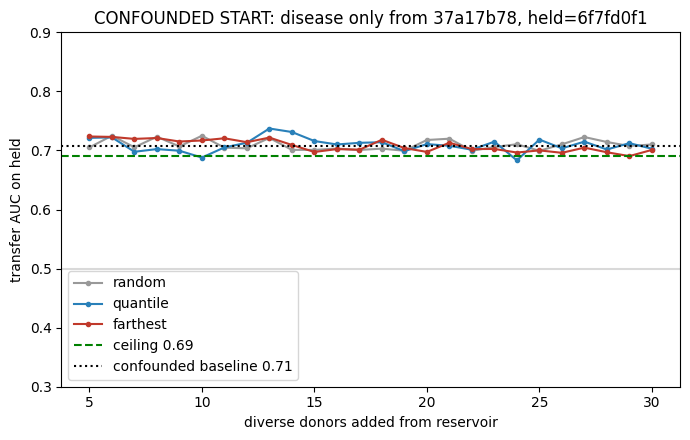

In [23]:
held_id  = "6f7fd0f1"
held     = lf[lf.study == held_id]
res      = lf[lf.study != held_id]
DIS_ST   = "37a17b78"                                   
CON_ST   = res.loc[res.y == 0, "study"].value_counts().idxmax()   

hy  = held.y.to_numpy(); sc0 = StandardScaler().fit(held[Sc])
ceil = roc_auc_score(hy, cross_val_predict(LogisticRegression(C=0.01, max_iter=5000),
        sc0.transform(held[Sc]), hy, cv=StratifiedKFold(5, shuffle=True, random_state=0),
        method="predict_proba")[:, 1])

rng  = np.random.default_rng(0)
core = (list(rng.choice(res.index[(res.study == DIS_ST) & (res.y == 1)], 15, replace=False)) +
        list(rng.choice(res.index[(res.study == CON_ST) & (res.y == 0)], 15, replace=False)))
base_conf = fit_transfer(lf.loc[core], held)           
addpool = [i for i in res.index if i not in core]      

plt.figure(figsize=(7, 4.5))
for arm, col in [("random", "0.6"), ("quantile", "#2980b9"), ("farthest", "#c0392b")]:
    ks = list(range(5, 31, 1)); curves = []
    for s in range(15 if arm == "random" else 5):
        rng = np.random.default_rng(s)
        curves.append([fit_transfer(lf.loc[core + pick(addpool, k, arm, rng)], held) for k in ks])
    plt.plot(ks, np.mean(curves, 0), "-o", ms=3, color=col, label=arm)
plt.axhline(ceil, ls="--", color="green", label=f"ceiling {ceil:.2f}")
plt.axhline(base_conf, ls=":", color="black", label=f"confounded baseline {base_conf:.2f}")
plt.axhline(0.5, color="0.85")
plt.title(f"CONFOUNDED START: disease only from {DIS_ST}, held={held_id}")
plt.xlabel("diverse donors added from reservoir"); plt.ylabel("transfer AUC on held")
plt.legend(); plt.ylim(0.3, 0.9); plt.tight_layout(); plt.show()


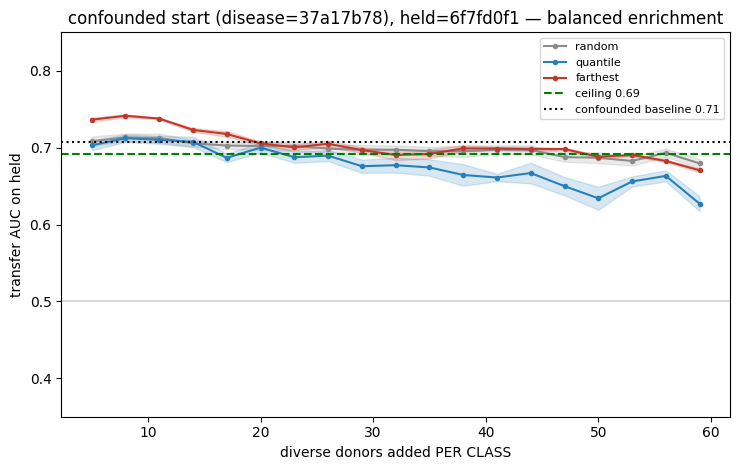

In [25]:
disA = [i for i in addpool if lf.loc[i, "y"] == 1]    
conA = [i for i in addpool if lf.loc[i, "y"] == 0]

plt.figure(figsize=(7.5, 4.8))
ks = list(range(5, 61, 3))
for arm, col in [("random", "0.55"), ("quantile", "#2980b9"), ("farthest", "#c0392b")]:
    curves = []
    for s in range(30 if arm == "random" else 12):     
        rng = np.random.default_rng(s)
        row = [fit_transfer(lf.loc[core + pick(disA, k, arm, rng) + pick(conA, k, arm, rng)], held)
               for k in ks]                           
        curves.append(row)
    curves = np.array(curves); m = curves.mean(0); se = curves.std(0) / np.sqrt(len(curves))
    plt.plot(ks, m, "-o", ms=3, color=col, label=arm)
    plt.fill_between(ks, m - se, m + se, color=col, alpha=0.18)   
plt.axhline(ceil, ls="--", color="green", label=f"ceiling {ceil:.2f}")
plt.axhline(base_conf, ls=":", color="black", label=f"confounded baseline {base_conf:.2f}")
plt.axhline(0.5, color="0.85")
plt.title(f"confounded start (disease={DIS_ST}), held={held_id} — balanced enrichment")
plt.xlabel("diverse donors added PER CLASS"); plt.ylabel("transfer AUC on held")
plt.legend(fontsize=8); plt.ylim(0.35, 0.85); plt.tight_layout(); plt.show()


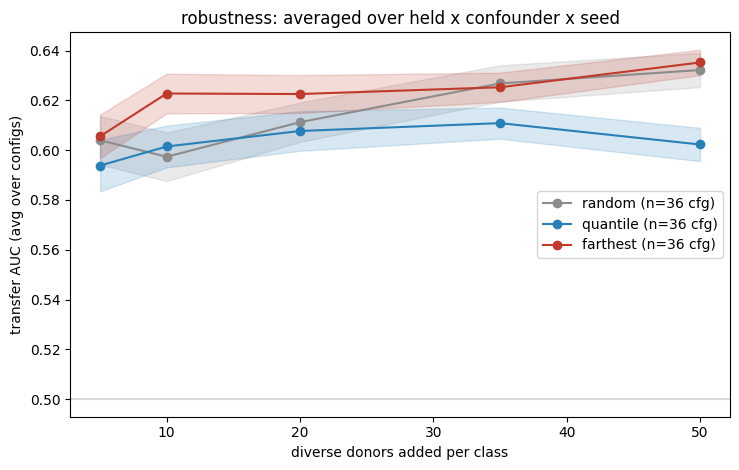

In [26]:
DEM = ["37a17b78", "6f7fd0f1", "5e57cd50"]
KS  = [5, 10, 20, 35, 50]

def run_cfg(held_id, dis_st, seed):
    held = lf[lf.study == held_id]; res = lf[lf.study != held_id]
    con_st = res.loc[res.y == 0, "study"].value_counts().idxmax()
    rng = np.random.default_rng(seed)
    dsrc = res.index[(res.study == dis_st) & (res.y == 1)]
    csrc = res.index[(res.study == con_st) & (res.y == 0)]
    if len(dsrc) < 15 or len(csrc) < 15: return None
    core = list(rng.choice(dsrc, 15, replace=False)) + list(rng.choice(csrc, 15, replace=False))
    addD = [i for i in res.index if i not in core and lf.loc[i, "y"] == 1]
    addC = [i for i in res.index if i not in core and lf.loc[i, "y"] == 0]
    out = {}
    for arm in ["random", "quantile", "farthest"]:
        out[arm] = [fit_transfer(lf.loc[core + pick(addD, k, arm, rng) + pick(addC, k, arm, rng)],
                                 held) for k in KS if k <= min(len(addD), len(addC))]
    return out

# sweep: every held x every other-dementia confounder x several core seeds
agg = {a: [] for a in ["random", "quantile", "farthest"]}
for h in DEM:
    for dconf in [d for d in DEM if d != h]:
        for s in range(6):
            r = run_cfg(h, dconf, s)
            if r: 
                for a in r: 
                    if len(r[a]) == len(KS): agg[a].append(r[a])

plt.figure(figsize=(7.5, 4.8))
for a, col in [("random", "0.55"), ("quantile", "#2980b9"), ("farthest", "#c0392b")]:
    C = np.array(agg[a]); m = C.mean(0); se = C.std(0) / np.sqrt(len(C))
    plt.plot(KS, m, "-o", color=col, label=f"{a} (n={len(C)} cfg)")
    plt.fill_between(KS, m - se, m + se, color=col, alpha=0.18)
plt.xlabel("diverse donors added per class"); plt.ylabel("transfer AUC (avg over configs)")
plt.title("robustness: averaged over held x confounder x seed"); plt.legend()
plt.axhline(0.5, color="0.85"); plt.tight_layout(); plt.show()


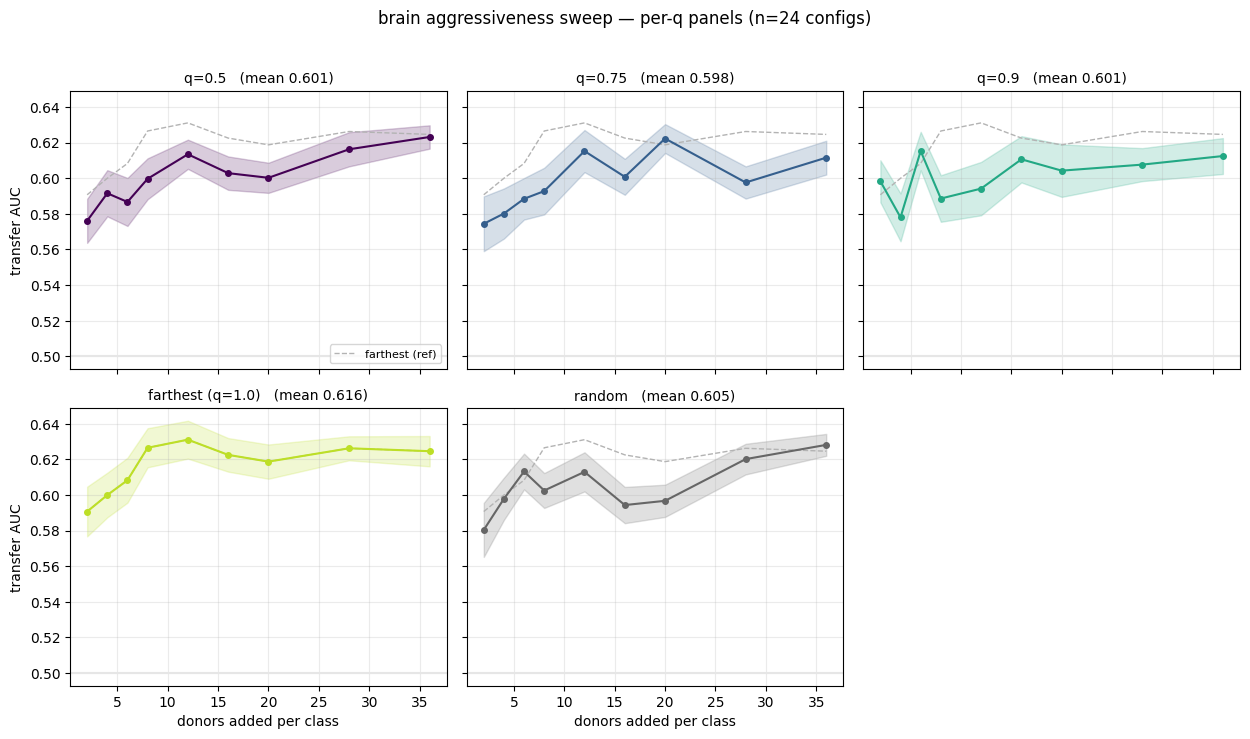

mean transfer AUC (averaged over cohort sizes):
  0.5       0.6011
  0.75      0.5981
  0.9       0.6010
  1.0       0.6165
  random    0.6051


In [29]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "scripts")
from selection import cosine_distance_matrix, greedy_quantile
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- data + helpers (self-contained) ---
lf = pd.read_parquet("data/brain/signatures_lf_pfc.parquet").reset_index(drop=True)
Sc = [c for c in lf.columns if c.startswith("s") and c[1:].isdigit()]
Dall = cosine_distance_matrix(lf[Sc].to_numpy())          # patient-patient distance
DEM  = ["37a17b78", "6f7fd0f1", "5e57cd50"]
KS   = [2, 4, 6, 8, 12, 16, 20, 28, 36]
QS   = [0.5, 0.75, 0.9, 1.0]                              # 1.0 == farthest

def fit_transfer(tr, held):
    sc  = StandardScaler().fit(tr[Sc])
    clf = LogisticRegression(C=0.01, max_iter=5000).fit(sc.transform(tr[Sc]), tr.y)
    return roc_auc_score(held.y, clf.predict_proba(sc.transform(held[Sc]))[:, 1])

def pick_q(idx, k, q, rng):
    idx = list(idx)
    if len(idx) <= k: return idx
    seed = [int(rng.choice(idx))]; rest = [i for i in idx if i != seed[0]]
    return seed + greedy_quantile(Dall, seed, rest, k - 1, q)

def pick_rand(idx, k, rng):
    idx = list(idx)
    return idx if len(idx) <= k else list(rng.choice(idx, k, replace=False))

def cfg_curves(held_id, dis_st, seed):
    held = lf[lf.study == held_id]; res = lf[lf.study != held_id]
    con_st = res.loc[res.y == 0, "study"].value_counts().idxmax()
    rng = np.random.default_rng(seed)
    dsrc = res.index[(res.study == dis_st) & (res.y == 1)]
    csrc = res.index[(res.study == con_st) & (res.y == 0)]
    if len(dsrc) < 15 or len(csrc) < 15: return None
    core = list(rng.choice(dsrc, 15, replace=False)) + list(rng.choice(csrc, 15, replace=False))
    addD = [i for i in res.index if i not in core and lf.loc[i, "y"] == 1]
    addC = [i for i in res.index if i not in core and lf.loc[i, "y"] == 0]
    if min(len(addD), len(addC)) < max(KS): return None
    out = {q: [fit_transfer(lf.loc[core + pick_q(addD, k, q, rng) + pick_q(addC, k, q, rng)], held)
               for k in KS] for q in QS}
    out["random"] = [fit_transfer(
        lf.loc[core + pick_rand(addD, k, rng) + pick_rand(addC, k, rng)], held) for k in KS]
    return out

# --- sweep over held x confounder x seed ---
agg = {q: [] for q in QS + ["random"]}
for h in DEM:
    for dconf in [d for d in DEM if d != h]:
        for s in range(4):
            r = cfg_curves(h, dconf, s)
            if r:
                for key in agg: agg[key].append(r[key])

# --- plot ---
keys = QS + ["random"]
anchor = np.array(agg[1.0]).mean(0)            # farthest as a fixed reference in every panel
ncol = 3; nrow = int(np.ceil(len(keys) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow),
                         sharey=True, sharex=True)
axes = axes.ravel()
cols = dict(zip(QS, plt.cm.viridis(np.linspace(0, 0.9, len(QS)))))
cols["random"] = "0.4"

for ax, key in zip(axes, keys):
    C = np.array(agg[key]); m = C.mean(0); se = C.std(0) / np.sqrt(len(C))
    c = cols[key]
    ax.plot(KS, anchor, "--", color="0.7", lw=1, label="farthest (ref)")   # anchor
    ax.plot(KS, m, "-o", color=c, ms=4)
    ax.fill_between(KS, m - se, m + se, color=c, alpha=0.2)
    lbl = "farthest (q=1.0)" if key == 1.0 else ("random" if key == "random" else f"q={key}")
    ax.set_title(f"{lbl}   (mean {m.mean():.3f})", fontsize=10)
    ax.axhline(0.5, color="0.9")
    ax.grid(alpha=0.25)
for ax in axes[len(keys):]:            # hide unused panels
    ax.set_visible(False)
for ax in axes[::ncol]:
    ax.set_ylabel("transfer AUC")
for ax in axes[-ncol:]:
    ax.set_xlabel("donors added per class")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(f"brain aggressiveness sweep — per-q panels (n={len(agg[1.0])} configs)", y=1.02)
fig.tight_layout(); plt.show()

# --- numeric summary: mean AUC per q, averaged over cohort sizes ---
print("mean transfer AUC (averaged over cohort sizes):")
for q in QS + ["random"]:
    print(f"  {str(q):8s}  {np.array(agg[q]).mean():.4f}")
